In [7]:
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris as iris
import seaborn as sns
import pandas as pd

In [8]:
iris_dataset = iris()
df = pd.DataFrame(data=iris_dataset.data, columns = iris_dataset.feature_names)
df['species'] = pd.Categorical.from_codes(iris_dataset.target, iris_dataset.target_names)


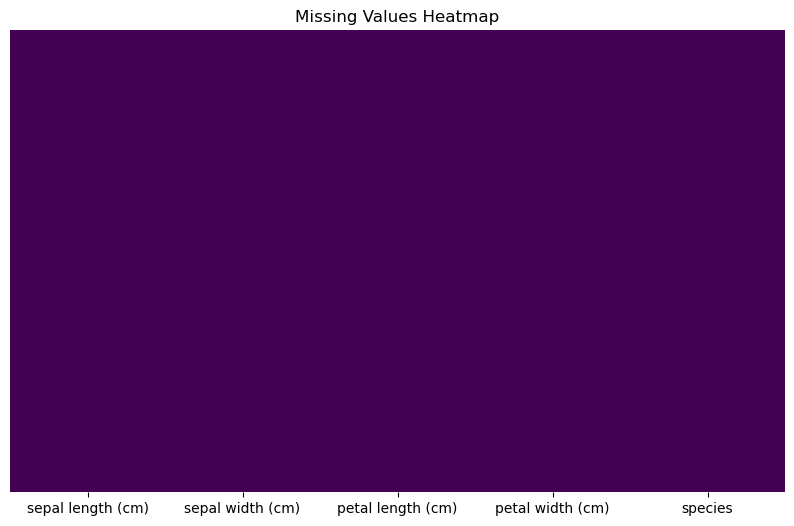

In [11]:
# 1. Missing Values Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

Thaks to the fact that the the Heat Map of the dataset is a block of purple, withou any lines of another color, we deduce that no data is missing 

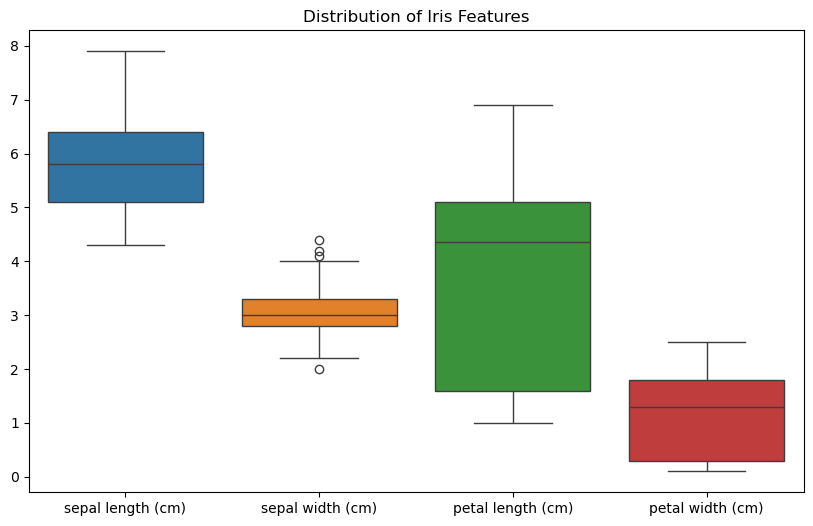

In [12]:
# 2. Distribution Boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Distribution of Iris Features')
plt.show()

We notice that the "Sepal Width" feature is the most simmetric one (few outliers), this gives us a hint that it will probably be the feature that we are going to test the normality assumptio of its distribution 

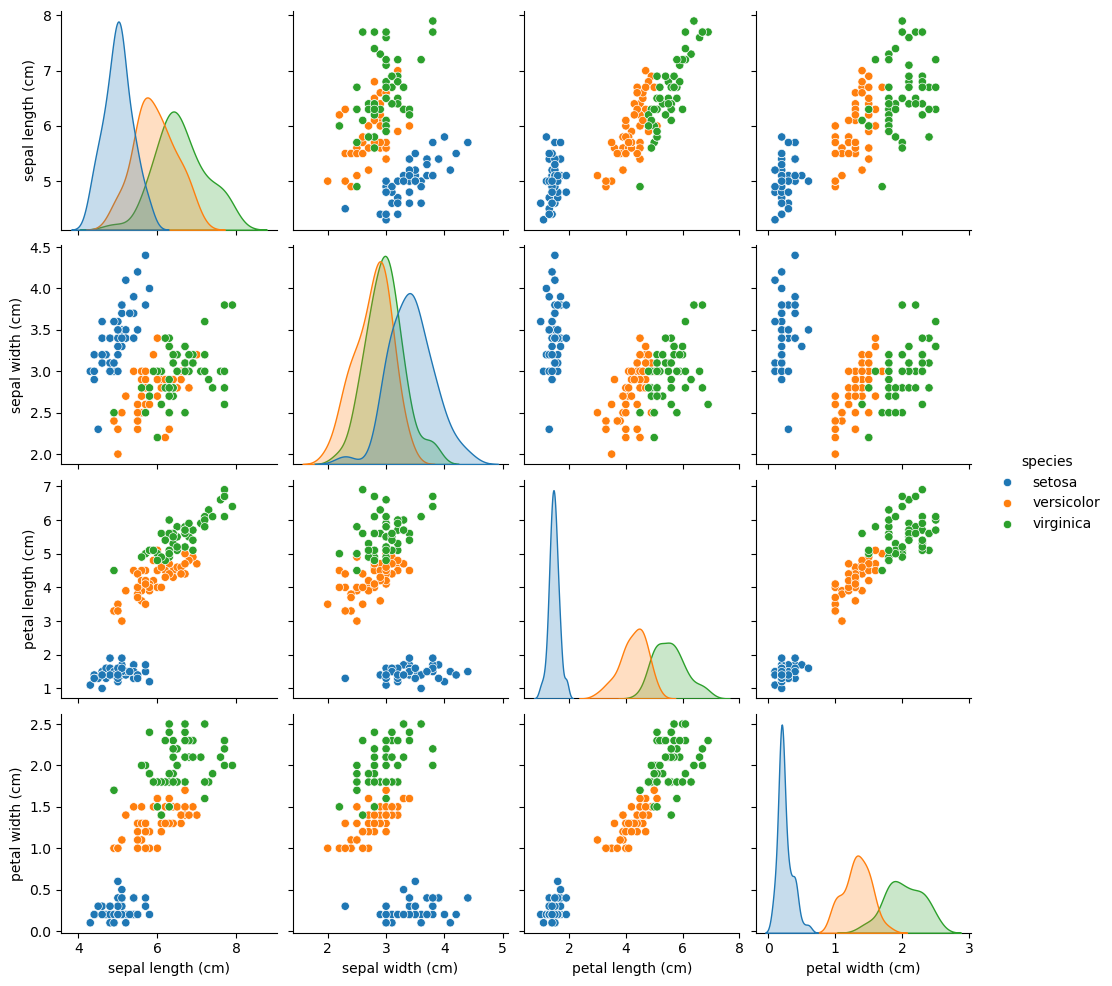

In [13]:
# 3. Pair Plot
sns.pairplot(df, hue='species')
plt.show()

The Pair Plot gives us another hint that the Sepal width is the only features that can be normal beacuse is not divided in clusters as the others features.

Now we want to Test the normality of the all features.

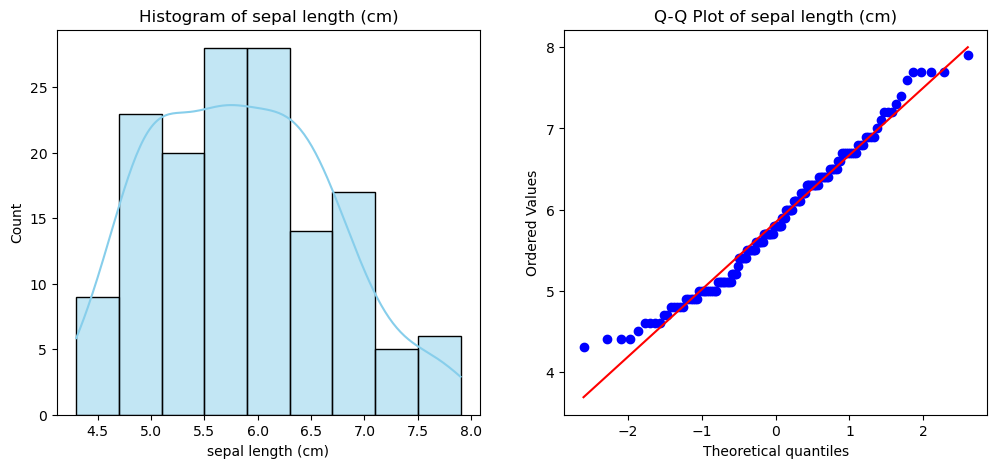

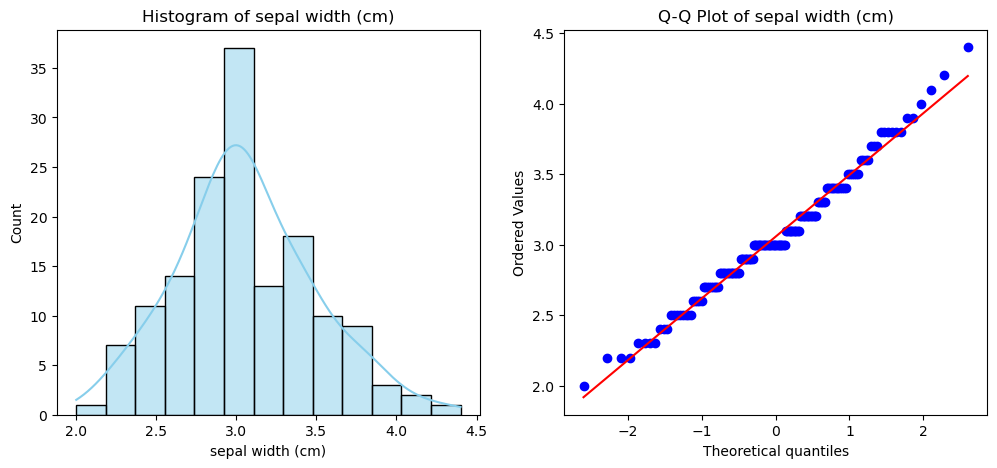

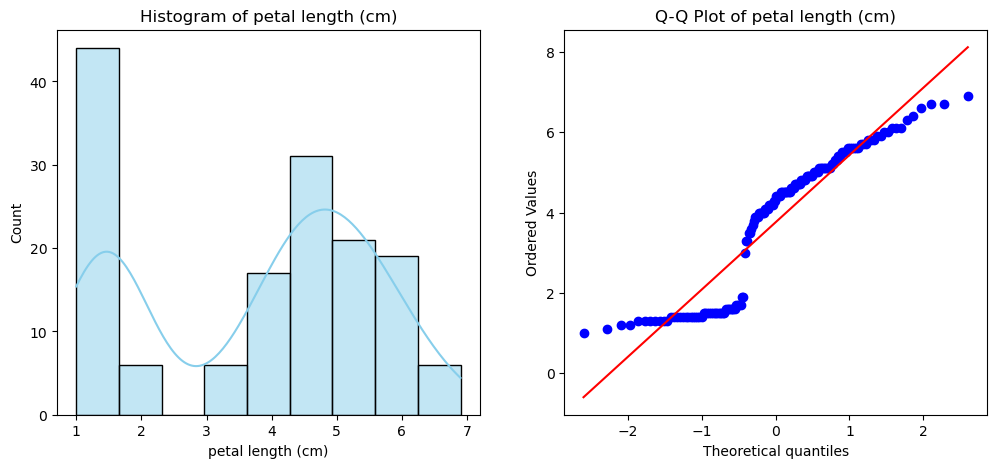

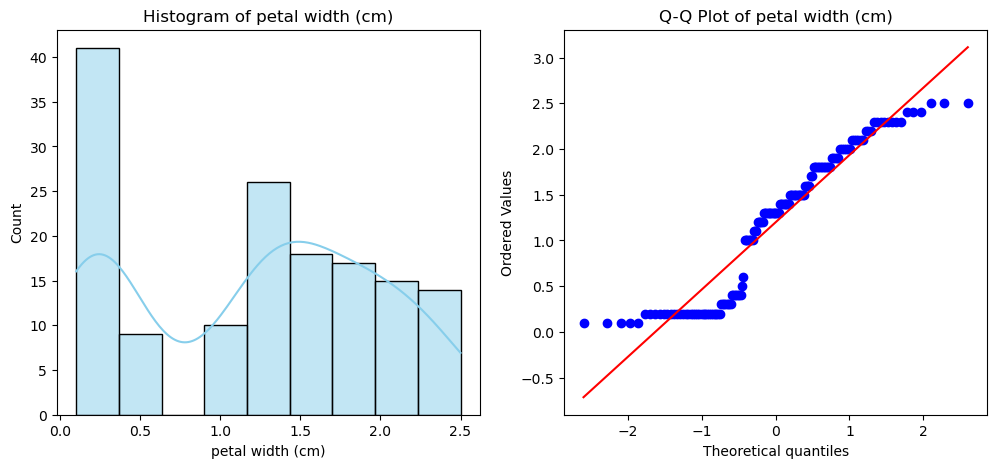

In [17]:
feature = iris_dataset.feature_names

for name in feature:
    # --- 1. Visual Method: Q-Q Plot ---
    plt.figure(figsize=(12, 5))

    # Subplot 1: Histogram with Bell Curve (KDE)
    plt.subplot(1, 2, 1)
    sns.histplot(df[name], kde=True, color='skyblue')
    plt.title(f'Histogram of {name}')

    # Subplot 2: Q-Q Plot
    plt.subplot(1, 2, 2)
    st.probplot(df[name], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {name}')

    plt.show()



From the Q-Q plot we can say that the only features that can be distributed as normal among all species are the first two:
- SEPAL LENGTH
- SEPAL WIDTH 

To be sure that the assumption of normality of the features is correct we decide also to run a Shapiro-Wilk Test, given the "small" number of observation available in the dataset 

In [27]:
feature = iris_dataset.feature_names[0:2]

for name in feature:
    # --- 2. Statistical Method: Shapiro-Wilk Test ---
    stat, p_value = st.shapiro(df[name])

    print(f"Shapiro-Wilk Test for '{name}':")
    print(f"Statistic: {stat:.4f}")
    print(f"P-Value:   {p_value:.4f}")

    if p_value > 0.05:
        print("✅ Result: The data looks Gaussian (Normal).")
    else:
        print("❌ Result: The data does NOT look Gaussian (Not Normal).")

Shapiro-Wilk Test for 'sepal length (cm)':
Statistic: 0.9761
P-Value:   0.0102
❌ Result: The data does NOT look Gaussian (Not Normal).
Shapiro-Wilk Test for 'sepal width (cm)':
Statistic: 0.9849
P-Value:   0.1012
✅ Result: The data looks Gaussian (Normal).


So the only feature that can be Nomally distributed is the **SEPAL WIDTH** as we noticed from the Pair Plot